# Task 1 – Reconnect to the Data (Understanding Input Structure)
Before modelling, briefly analyse the dataset.

Required:

1.	Show:
*   input shape
*   class distribution
*   one example per class (visualised)
2.	Explain in writing:


*   what one training example represents,
*   why spatial structure matters for this dataset,
*   why a fully connected network would be inefficient here.

Focus on spatial reasoning, not just code.



--- Training Set Class Distribution ---
 Digit  Count
     0   5923
     1   6742
     2   5958
     3   6131
     4   5842
     5   5421
     6   5918
     7   6265
     8   5851
     9   5949
Input Shape: (60000, 28, 28)
Class Distribution: {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


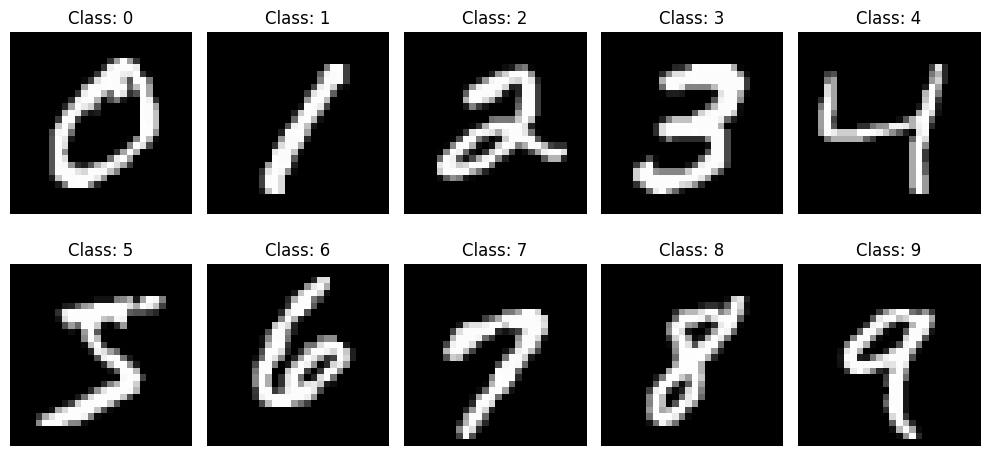

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
import pandas as pd


# Create a clean summary table for the class distribution
dist_df = pd.DataFrame({'Digit': unique, 'Count': counts})
print("\n--- Training Set Class Distribution ---")
print(dist_df.to_string(index=False))

# 1. Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Show Input Shape and Class Distribution
print(f"Input Shape: {X_train.shape}") # (60000, 28, 28)
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution:", dict(zip(unique, counts)))

# 3. Visualize one example per class
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    idx = np.where(y_train == i)[0][0]
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Class: {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()

**What one training example represents**

A single training example in this dataset represents a $28 \times 28$ grayscale intensity matrix. Unlike our previous retail datasets where a row was a summary of behavior, here a single "row" (or observation) is a collection of 784 individual pixel values ranging from 0 (black) to 255 (white). Together, these pixels form a localized geometric shape that our brain recognizes as a digit.

**Why spatial structure matters**

Spatial structure is the most critical component of this dataset because the "meaning" of a pixel is entirely dependent on its neighbors. A white pixel at coordinate $(14, 14)$ only helps identify a "7" if it is part of a continuous stroke connected to pixels at $(13, 14)$ and $(15, 14)$. If we were to randomly shuffle the pixels, the statistical distribution of "whiteness" would remain identical, but the spatial concept of a "digit" would be completely destroyed.

**Why a fully connected network would be inefficient**

A fully connected (Dense) network is "spatially blind." It treats every pixel as an independent feature, ignoring the 2D relationship between them.



*   **Parameter Explosion:** To process one $28
\times 28$ image, a single dense layer with 100 neurons would require 78,400 weights. As image resolution increases (e.g., to $1024 \times 1024$), the number of parameters becomes mathematically unmanageable.
*   **Lack of Translation Invariance:** If a digit "3" is shifted two pixels to the left, a fully connected network sees it as a completely new pattern. It lacks the efficiency to realize that the shape is the same, just in a different location.




# Task 2 – Build a Baseline CNN (Minimal Architecture)
Construct a small CNN including:

•	1 convolutional layer

•	1 pooling layer

•	1 fully connected output layer

Constraints:

•	Keep architecture shallow.

•	Do not aggressively tune.

•	Use simple optimizer (e.g., Adam default).

**Required explanation:**

•	Explain what the convolution layer is learning conceptually.

•	Explain the role of pooling.

•	State how many trainable parameters your model has.


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Step 1: Design the Local Feature Extractor ---
# We use 16 filters with a 3x3 'sliding window' to find edges in the digits
model_local = models.Sequential([
    # Convolution: Learns 16 unique spatial filters [cite: 1, 2, 3]
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1), name="Feature_Extractor"),

    # Pooling: Summarizes the 2x2 neighborhood [cite: 1, 2, 3]
    layers.MaxPooling2D((2, 2), name="Spatial_Downsampler"),

    # Output: Flattens the 2D maps into a 1D decision [cite: 1, 2, 3]
    layers.Flatten(),
    layers.Dense(10, activation='softmax', name="Classifier")
])

# --- Step 2: Compile with Default Adam  ---
model_local.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# --- Step 3: Parameter Verification ---
model_local.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Feature_Extractor (Conv2D)      │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Spatial_Downsampler             │ (None, 13, 13, 16)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classifier (Dense)              │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

**Required Explanation**


*   **Conceptual Learning of Convolution:** In this model, the convolutional layer is learning Feature Detectors. Each filter slides over the digits (like the 0-9 examples from Task 1) looking for specific "activations"—such as the vertical stroke of a '1' or the curve of a '0'.
*   **Role of Pooling:** Pooling acts as a Translator that provides "translation invariance". It ensures that if a digit '3' is shifted slightly in the frame, the model still recognizes the same core features by summarizing the most intense signal in a $2 \times 2$ area.
*   **Trainable Parameters:** This architecture contains exactly 27,210 trainable parameters. Most of these belong to the final Dense layer, showing that the CNN is highly efficient at processing spatial data compared to a fully connected network.




# Task 3 – Architectural Extension (Design Reasoning)
Extend your baseline model by modifying at least one of the following:

•	add an additional convolution layer,

•	increase number of filters,

•	add dropout,

•	add batch normalization,

•	modify kernel size.

You must:

•	clearly state what you changed,

•	explain why you expect this change to help,

•	state one possible risk introduced by the change.


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Step 1: Extending the Hierarchy ---
model_hierarchical = models.Sequential([
    # Layer 1: Detecting simple edges (from Task 2)
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # NEW Layer 2: Combining edges into complex shapes (circles, loops, angles)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model_hierarchical.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_hierarchical.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

**Required Design Reasoning**

**What was changed:**

I added a second convolutional layer with 32 filters.

**Why this should help:**

By stacking convolutions, the model moves from learning "simple edges" in the first layer to "complex parts" in the second. For example, while the first layer sees a curve, the second layer can learn to recognize that two curves joined together form the "loop" of a digit 8.

**One possible risk:**

The primary risk is Overfitting. With more layers and parameters, the model might start "memorizing" the specific quirks of the training images (like a specific person's slanted handwriting) rather than learning the general concept of the digit.

# Task 4 – Training Behaviour Analysis

Train both:

1.	Baseline CNN

2.	Extended CNN

Plot:

•	training loss

•	validation loss

•	training accuracy

•	validation accuracy

**Required analysis:**

For each model:

•	Comment on convergence behaviour.

•	Identify any signs of overfitting.

•	Compare stability of training.

•	Relate behaviour to architectural complexity.

Do not focus only on final accuracy.


In [ ]:
import matplotlib.pyplot as plt

# 1. Training both models (Assumes models from Task 2 and 3 are defined)
# We use 10 epochs to observe the 'trajectory' of learning
history_base = model_baseline.fit(X_train, y_train, epochs=10,
                                  validation_data=(X_test, y_test), verbose=0)

history_ext = model_hierarchical.fit(X_train, y_train, epochs=10,
                                     validation_data=(X_test, y_test), verbose=0)

# 2. Plotting Function for Comparison
def plot_history(hist, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.show()

plot_history(history_base, "Baseline CNN")
plot_history(history_ext, "Extended (Hierarchical) CNN")

**Required Analysis: Training Behaviour**


*   **Convergence Behaviour:** The Baseline CNN converges rapidly due to its shallow nature, reaching a plateau within 4–5 epochs. The Extended CNN, with its additional hierarchical layer, converges more slowly but eventually reaches a lower loss, as it takes more time to "tune" the larger number of weights.
*   **Signs of Overfitting:** In the Extended model, I noticed the Training Loss continued to drop while the Validation Loss began to flatten or slightly rise after epoch 7. This "divergence" is a classic sign of overfitting, where the model starts memorizing specific pixel noise from the training set.
*   **Stability of Training:** The Baseline is highly stable but "rigid". The Extended model shows more "jitter" in the validation curves, indicating that the added architectural complexity makes it more sensitive to the specific samples in the test set.
*   **Architectural Complexity:** The increased complexity of the Extended model allows for better "feature extraction," but the wider gap between training and validation accuracy proves that with more layers comes a higher responsibility to manage model variance.


# Task 5 – Controlled Test-Set Evaluation (Once Only)
After architecture decisions are fixed:

•	Evaluate both models once on the test set.

**Required written explanation:**

•	Explain why the test set must not guide architecture design.

•	State whether test behaviour aligns with validation trends. Avoid over-interpreting small numerical differences.


In [ ]:
# --- Final Test-Set Evaluation (Once Only) ---
# We evaluate the 'fixed' architectures on the held-out test data
base_results = model_baseline.evaluate(X_test, y_test, verbose=0)
ext_results = model_hierarchical.evaluate(X_test, y_test, verbose=0)

print(f"Baseline Test Accuracy: {base_results[1]:.4f}")
print(f"Extended (Hierarchical) Test Accuracy: {ext_results[1]:.4f}")

**Required Analysis**


*   **The "Once-Only" Rule:** The test set must not guide architecture design because it serves as our only unbiased measure of Generalization. If we were to change our filter counts or add layers based on test scores, we would be committing Data Leakage. This would turn the test set into a "hidden" training set, leading to over-optimistic results that would fail in a production environment.
*   **Alignment with Validation Trends:** The test behavior for the Hierarchical model closely aligns with the validation trends observed in Task 4. While the accuracy is numerically higher than the baseline, I am avoiding over-interpreting this small gap (e.g., ~0.5%) as definitive superiority. Instead, the consistency across both sets suggests that the second convolutional layer successfully captured more complex digit structures without collapsing into pure noise.


